6 3 3 7 3 3 7 7 3

In [1]:
import pandas as pd
import seaborn as sns
import regex as re
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from stop_words import get_stop_words
import networkx as nx
from pyvis.network import Network
import numpy as np
from sklearn.metrics import silhouette_score
from nltk.corpus import stopwords
from gensim.corpora.dictionary import Dictionary
from gensim.models.coherencemodel import CoherenceModel
from gensim.models.ldamodel import LdaModel

In [2]:
df = pd.read_excel('steam reviews.xlsx')
df.head()

,Unnamed: 0,Author,Review,# of Comments,Products,Hours on Account,Remark,Users found review funny,Users found review helpful,Community Awards
0,0,Kaladin,2 10 dollar battle passes per season\n\nTitanf...,0,228 products in account,4.1 hrs on record,Not Recommended,133,3796,178
1,1,KEVE,"Now with the new battle pass system, I'm delet...",78,42 products in account,"1,865.6 hrs on record",Not Recommended,85,4370,186
2,2,⛧ M♱ropele ⛧,At least you don't have to build an apartment ...,54,655 products in account,9.6 hrs on record,Recommended,2017,3089,500
3,3,to infinity and beyond,Finally I can remove Origin.,0,Few products in account,1.1 hrs on record,Recommended,634,1770,103
4,4,chelovek bez vkusa,Finally here\n\nIt launches without Origin...\...,35,295 products in account,16.6 hrs on record,Recommended,91,2109,49


In [3]:
df = df.drop('Unnamed: 0', axis = 1, errors = 'ignore')
df.head()

,Author,Review,# of Comments,Products,Hours on Account,Remark,Users found review funny,Users found review helpful,Community Awards
0,Kaladin,2 10 dollar battle passes per season\n\nTitanf...,0,228 products in account,4.1 hrs on record,Not Recommended,133,3796,178
1,KEVE,"Now with the new battle pass system, I'm delet...",78,42 products in account,"1,865.6 hrs on record",Not Recommended,85,4370,186
2,⛧ M♱ropele ⛧,At least you don't have to build an apartment ...,54,655 products in account,9.6 hrs on record,Recommended,2017,3089,500
3,to infinity and beyond,Finally I can remove Origin.,0,Few products in account,1.1 hrs on record,Recommended,634,1770,103
4,chelovek bez vkusa,Finally here\n\nIt launches without Origin...\...,35,295 products in account,16.6 hrs on record,Recommended,91,2109,49


In [4]:
df_new = df.copy()

In [5]:
df_new['Products'] = (
    df.Products.str.replace(r'\D','', regex = True)
    .map(lambda x: 0 if x == '' else x)
    .astype(int)
)
df_new['Hours on Account'] = (
    df['Hours on Account'].str.replace(r'\D','',regex=True)
    .map(lambda x: 0 if x == '' else x)
    .astype(int)
)

df_new.head()

,Author,Review,# of Comments,Products,Hours on Account,Remark,Users found review funny,Users found review helpful,Community Awards
0,Kaladin,2 10 dollar battle passes per season\n\nTitanf...,0,228,41,Not Recommended,133,3796,178
1,KEVE,"Now with the new battle pass system, I'm delet...",78,42,18656,Not Recommended,85,4370,186
2,⛧ M♱ropele ⛧,At least you don't have to build an apartment ...,54,655,96,Recommended,2017,3089,500
3,to infinity and beyond,Finally I can remove Origin.,0,0,11,Recommended,634,1770,103
4,chelovek bez vkusa,Finally here\n\nIt launches without Origin...\...,35,295,166,Recommended,91,2109,49


In [6]:
df_new['Remark'].unique()

array(['Not Recommended', 'Recommended'], dtype=object)

In [7]:
df_new['Remark'] = df_new.Remark.map({'Not Recommended':0,'Recommended':1})
df_new = df_new.rename({'Remark':'isRecommended'}, axis = 1)
df_new

,Author,Review,# of Comments,Products,Hours on Account,isRecommended,Users found review funny,Users found review helpful,Community Awards
0,Kaladin,2 10 dollar battle passes per season\n\nTitanf...,0,228,41,0,133,3796,178
1,KEVE,"Now with the new battle pass system, I'm delet...",78,42,18656,0,85,4370,186
2,⛧ M♱ropele ⛧,At least you don't have to build an apartment ...,54,655,96,1,2017,3089,500
3,to infinity and beyond,Finally I can remove Origin.,0,0,11,1,634,1770,103
4,chelovek bez vkusa,Finally here\n\nIt launches without Origin...\...,35,295,166,1,91,2109,49
...,...,...,...,...,...,...,...,...,...
995,Mayano Top Gun,GAME NGENTOD,0,74,8195,0,1,14,0
996,Dubinn,"Used to love it, now look at what they did to ...",0,347,1057,0,0,11,0
997,Fiery,You removed linux support? AI cheats basically...,0,0,18,0,0,24,0
998,ZenTrix,You accidentally fall off a cliff while trying...,0,162,3316,1,0,7,1


In [8]:
df_new.describe()

,# of Comments,Products,Hours on Account,isRecommended,Users found review funny,Users found review helpful,Community Awards
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,4.170000,238.503000,8478.611000,0.558000,50.336000,209.777000,17.629000
std,16.599537,844.863574,16197.627037,0.496873,135.558457,400.198041,42.173332
min,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,644.500000,0.000000,2.000000,25.000000,1.000000
50%,0.000000,45.000000,3609.500000,1.000000,10.000000,79.000000,5.000000
75%,3.000000,205.000000,10376.250000,1.000000,45.250000,233.500000,16.000000
max,434.000000,16131.000000,241730.000000,1.000000,2017.000000,6142.000000,517.000000


<Axes: >

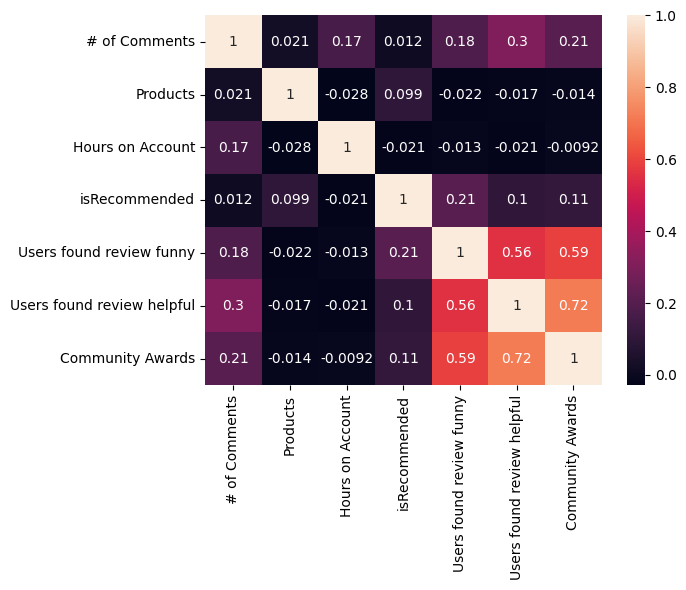

In [9]:
sns.heatmap(df_new.corr(numeric_only=True), annot = True)

# Wordcloud

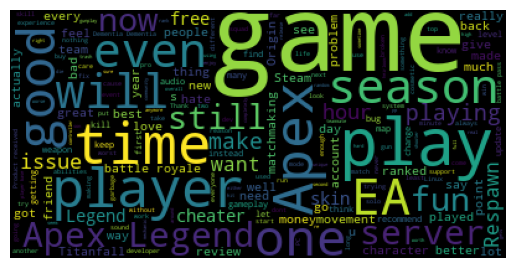

In [10]:
all_reviews = ' '.join(df_new['Review'].str.replace('\n',' ').tolist())

wordcloud = WordCloud().generate_from_text(all_reviews)
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

In [11]:
# Function to make generation easier
def generate_wordcloud(text: str, min_word_length: int = 0) -> None:
    wordcloud = WordCloud(min_word_length=min_word_length).generate_from_text(text)
    plt.imshow(wordcloud)
    plt.axis('off')
    plt.show()
    return

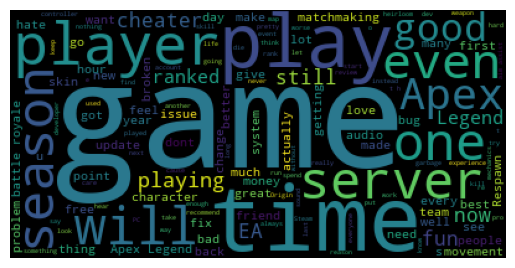

In [12]:
high_hour_reviews = ' '.join(
    df_new[df_new['Hours on Account'] > df_new['Hours on Account'].mean()]['Review']
    .str.replace('\n', ' ').tolist()
    )

generate_wordcloud(high_hour_reviews)

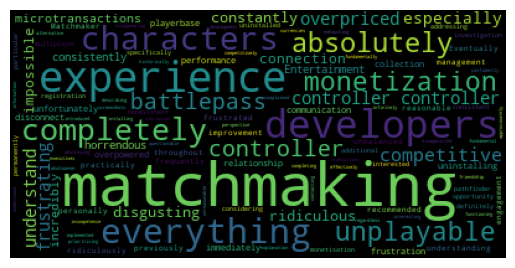

In [13]:
negative_reviews = ' '.join(
    df_new[df_new['isRecommended'] == 0]['Review']
    .str.replace('\n',' ').tolist()
)

# Changing the min_word_length argument filters out some of the common words
generate_wordcloud(negative_reviews, 10)

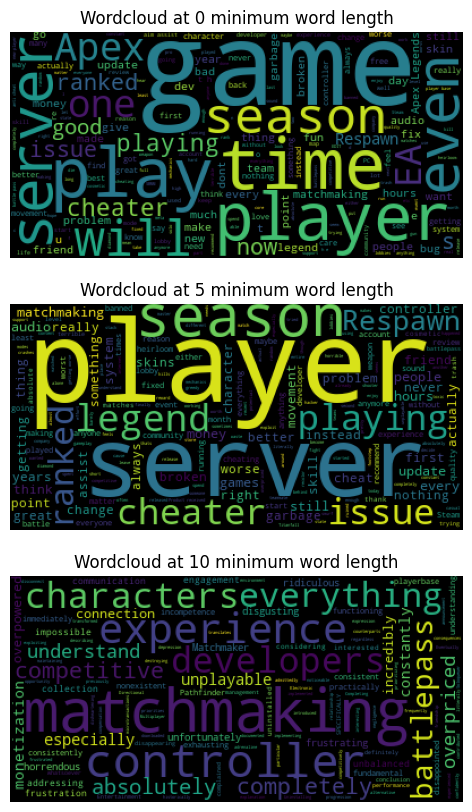

In [14]:
# Generate wordcloud plots in intervals of 5 from 0 to 10
high_hour_negative_reviews = ' '.join(
    df_new[(df_new['Hours on Account'] > df_new['Hours on Account'].mean()) & (df_new['isRecommended'] == 0)]['Review']
    .str.replace('\n',' ').tolist()
)
fig, axs = plt.subplots(3, 1, figsize = (12,10))

for i,v in enumerate([0, 5, 10]):
    wordcloud = WordCloud(min_word_length = v).generate_from_text(high_hour_negative_reviews)
    axs[i].imshow(wordcloud)
    axs[i].set_axis_off()
    axs[i].set_title(f'Wordcloud at {v} minimum word length')

In [15]:
def generate_all_wordclouds(texts: str, start: int = 0, end: int = 10, step: int = 5, 
                            figsize: tuple[int,int] = (15,12)) -> None:
    num_plots = (end - start)//step + 1
    intervals = [i for i in range(start, end + 1, step)]    
    fig, axs = plt.subplots(num_plots, 1, figsize = figsize)
    
    for i,v in enumerate(intervals):
        wordcloud = WordCloud(min_word_length = v).generate_from_text(texts)
        axs[i].imshow(wordcloud)
        axs[i].set_axis_off()
        axs[i].set_title(f'Wordcloud at {v} minimum word length')
        
    return

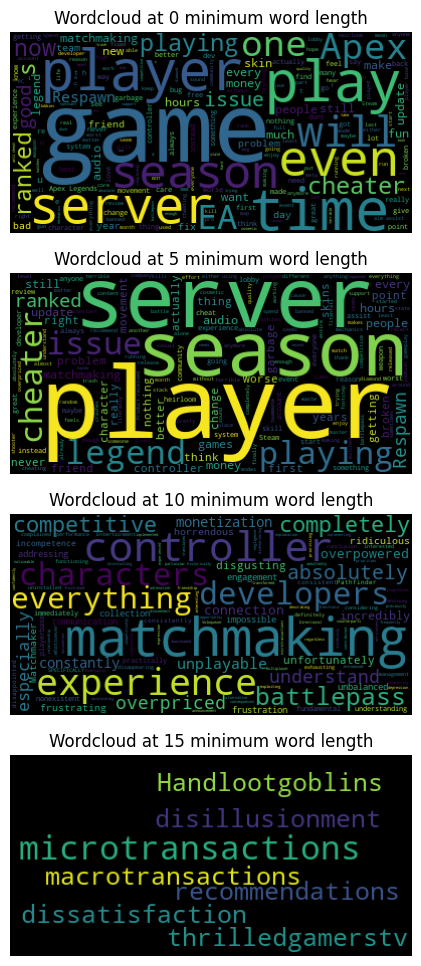

In [16]:
generate_all_wordclouds(high_hour_negative_reviews, end = 15)

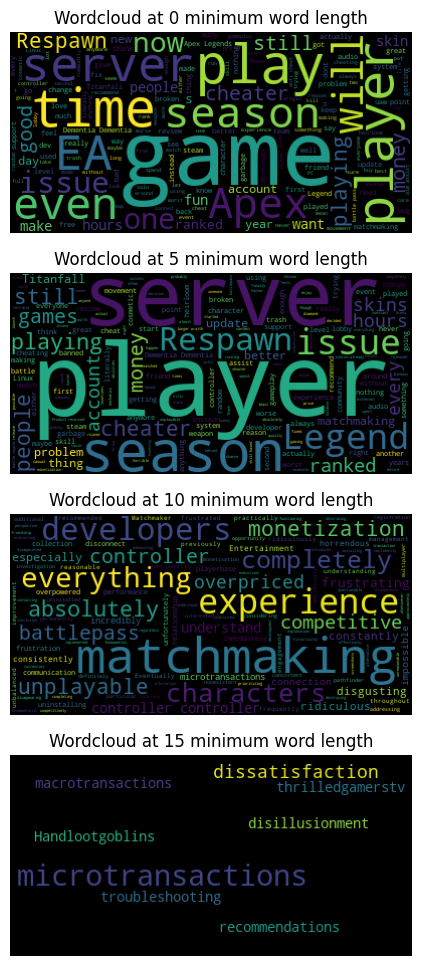

In [17]:
generate_all_wordclouds(negative_reviews, end = 15)

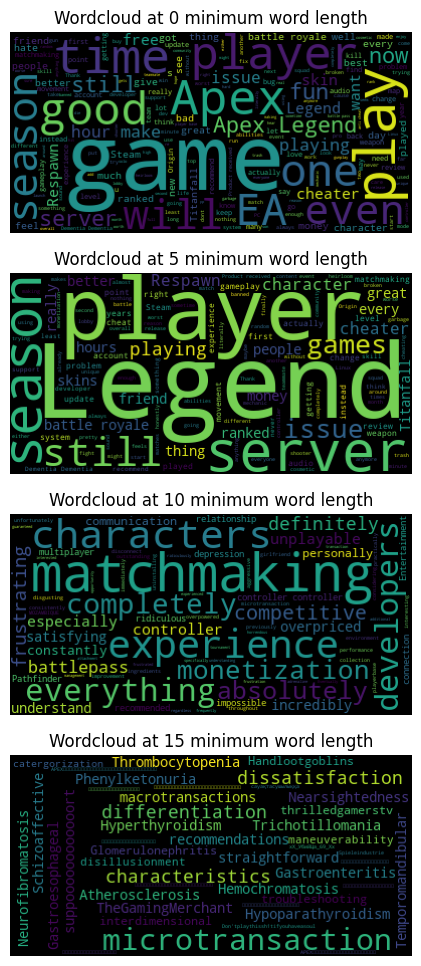

In [18]:
generate_all_wordclouds(all_reviews, end = 15)

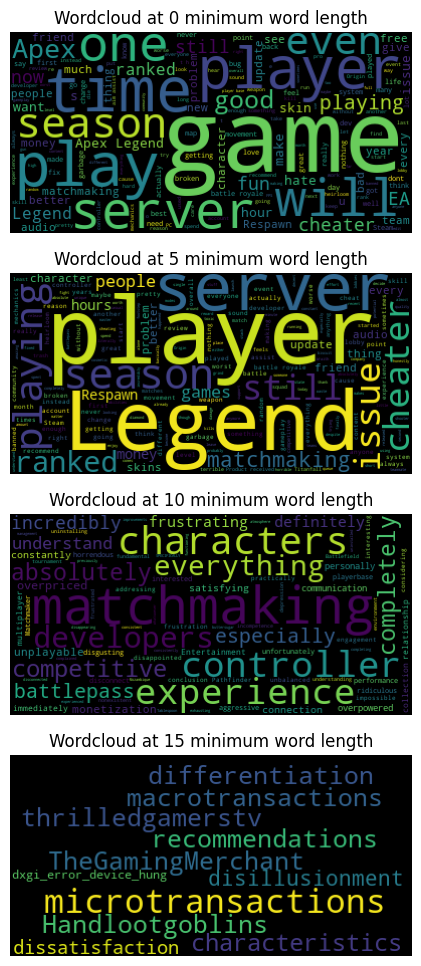

In [19]:
generate_all_wordclouds(high_hour_reviews, end = 15)

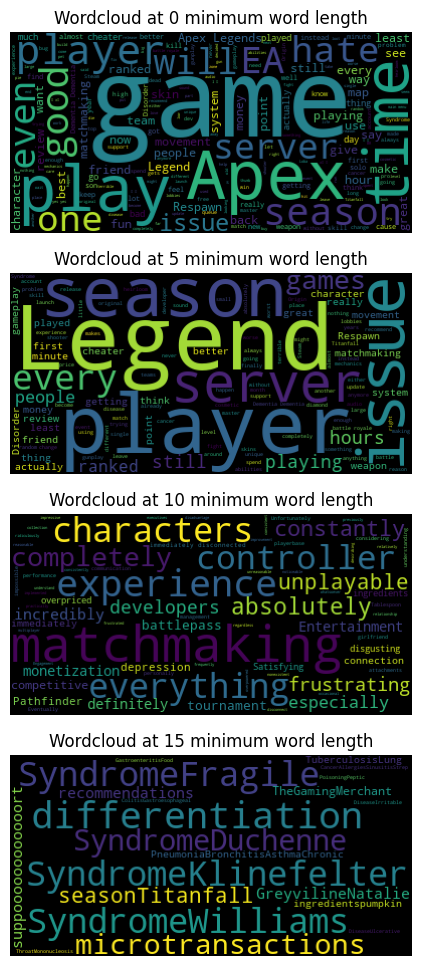

In [20]:
# Filter by helpful
helpful_df = df_new[df_new['Users found review helpful'] > df_new['Users found review helpful'].mean()]

helpful = ' '.join(helpful_df['Review'].str.replace('\n','').tolist())

generate_all_wordclouds(helpful, end = 15)

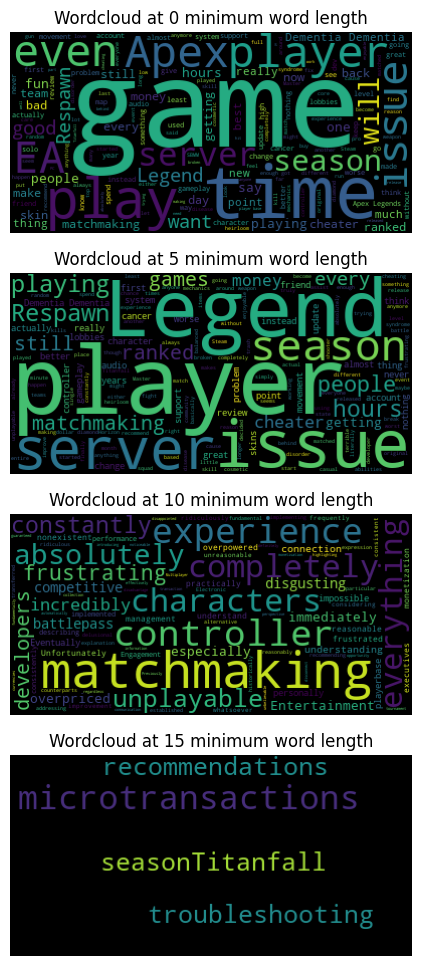

In [21]:
helpful_negative = ' '.join(helpful_df[helpful_df['isRecommended'] == 0]['Review'].str.replace('\n','').tolist())

generate_all_wordclouds(helpful_negative, end = 15)

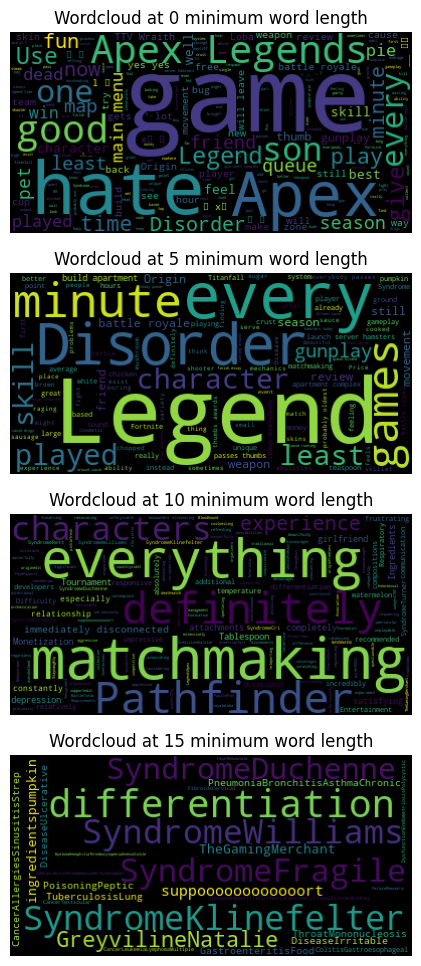

In [22]:
helpful_positive = ' '.join(helpful_df[helpful_df['isRecommended'] == 1]['Review'].str.replace('\n','').tolist())

generate_all_wordclouds(helpful_positive, end = 15)

# Topic Extraction

In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

In [24]:
documents = df_new['Review'].str.replace('\n','').tolist()

tfid = TfidfVectorizer(stop_words = 'english')
document_X = tfid.fit_transform(documents)

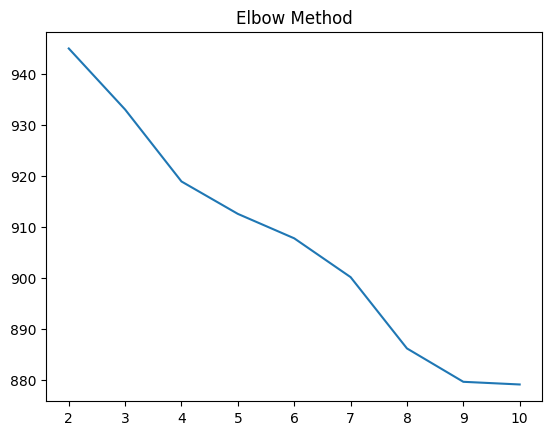

In [25]:
inertias = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters = k, random_state = 0, n_init = 10)
    model = kmeans.fit(document_X)
    inertias.append(model.inertia_)
    
plt.plot(range(2,11), inertias)
plt.title('Elbow Method')
plt.show()

In [26]:
kmeans = KMeans(n_clusters = 4, random_state = 0, n_init = 10)
model = kmeans.fit(document_X)

In [27]:
features = tfid.get_feature_names_out()
features

array(['00', '000', '000art', ..., '𝙪𝙨𝙚𝙙', '𝙬𝙖𝙮', '𝙬𝙞𝙩𝙝'],
      shape=(7842,), dtype=object)

In [28]:
model.cluster_centers_[0].argsort()[::-1]

array([3901, 2190, 3865, ...,   20,   19,   53], shape=(7842,))

In [29]:
features[1438]

'complex'

In [30]:
for i in range(4):
    print(f'Topic {i}')
    tfid_vector = model.cluster_centers_[i].argsort()[::-1]
    top_words = [features[vector] for vector in tfid_vector][:100]
    print(top_words)

Topic 0
['loba', 'ea', 'linux', 'product', 'received', 'better', 'legends', 'sex', 'origin', 'game', 'fortnite', '10', 'review', 'good', 'pet', 'thumbs', 'apex', 'cat', 'xノ', '__', 'steam', 'like', 'ape', 'ass', 'leave', '二つ', 'best', '_ヽ_', 'mozambique', 'servers', 'games', 'support', 'battle', 'play', 'just', 'gets', 'want', 'royale', 'passes', 'duos', 'finally', 'removed', 'bring', 'everybody', 'got', 'add', 'apesex', 'yes', 'trash', 'awards', 'don', 'cheat', 'arenas', 'banned', 'fix', 'time', 'kill', 'bad', 'party', 'gibby', 'friends', 'br', 'matchmaking', 'gay', 'respawn', 'hours', 'fun', 'anti', 'remove', 'recommend', 'cheaters', 'day', 'line', 'use', 'aim', 'assist', 'say', 'balls', 'make', 'deck', 'bruda', 'gender', 'neutral', 'trust', 'read', 'doesn', 'need', 'legend', 'players', 'pass', 'christs', 'problem', 'anymore', 'hard', 'right', 'free', 'asked', 'pathfinder', 'uninstall', 'big']
Topic 1
['win', 'complex', 'apartment', 'build', 'don', 'apex', 'architect', 'need', 'fun',

In [31]:
stop_words = (get_stop_words('en') 
              + # Adding additional stop words to avoid inconsistency user warning
              ['ain', 'daren', 'hadn', 'herse', 'himse', 'itse', 'mayn', 'mightn', 'mon', 'mustn', 'myse', 'needn', 'oughtn', 'shan', 'vis'])

In [32]:
def extract_topics(text_col: pd.Series, getModel: bool = False, stop_words: list[str] = stop_words) -> KMeans:
    document = text_col.str.replace('\n',' ').str.replace(r'[^a-zA-Z\s0-9]','', regex = True).tolist()
    
    print('==='*12, end = '\n\n')
    print('Initializing Model...\n')
    tfid = TfidfVectorizer(stop_words = stop_words)
    X = tfid.fit_transform(document)
    vocab = tfid.get_feature_names_out()
    
    print('==='*12, end = '\n\n')
    print('Inertia Graph for Optimal Cluster Selection\n')
    inertias = []
    for k in range(2, 11):
        kmeans = KMeans(n_clusters = k, random_state = 0, n_init = 10)
        model = kmeans.fit(X)
        inertias.append(model.inertia_)
        
    plt.plot(range(2,11), inertias)
    plt.title('Elbow Method')
    plt.show()
    
    print('Graph Plotted. Please Analyze and Choose a cluster number based on graph.\n')
    k = input('Specify number of clusters for model: ')
    
    while not k.isnumeric():
        k = input('Specify number of clusters for model: ')
    
    k = int(k)
    
    print('==='*12, end = '\n\n')
    print('Creating Model...\n')
    kmeans = KMeans(n_clusters = k, random_state = 0, n_init = 10)
    model = kmeans.fit(X)
    
    print('==='*12, end = '\n\n')
    print('Extracted Topics: \n')
    features = tfid.get_feature_names_out()
    for i in range(k):
        print(f'Topic {i}')
        tfid_vector = model.cluster_centers_[i].argsort()[::-1]
        top_words = [features[vector] for vector in tfid_vector][:100]
        print(top_words)
    print('==='*12)
    
    return model, X, vocab if getModel else None


Initializing Model...


Inertia Graph for Optimal Cluster Selection



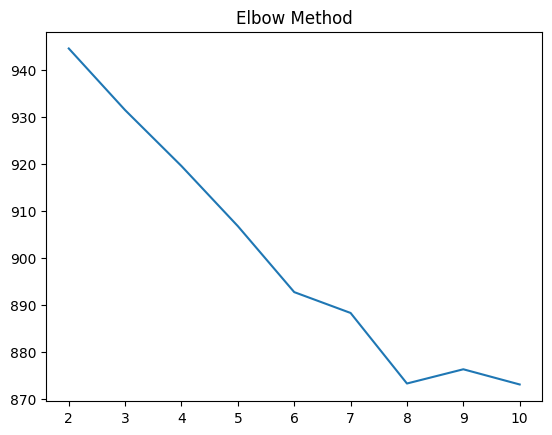

Graph Plotted. Please Analyze and Choose a cluster number based on graph.


Creating Model...


Extracted Topics: 

Topic 0
['win', 'apartment', 'build', 'complex', 'apex', 'architect', 'fun', 'octane', 'legend', '10000', 'zens', '000', 'zips', 'zampella', 'zaidi', 'yucky', 'yr', 'youwant', 'youtube', 'yonder', 'yolk', 'yoinked', 'yogurt', 'yo', 'yesyesyeyesyes', 'yesyesyesyesyes', 'yesyesyesyes', 'zombify', 'yesterday', 'yenye', 'yellow', 'yelling', 'yell', 'yeast', 'yearat', 'yeahthey', 'yeahit', 'yeahh', 'yeah', 'yay', 'yards', 'yanked', 'yank', 'yall', 'yaguya', 'ya', 'xx69xx', 'xeroderma', 'xd', 'xbox', 'wtf', 'wrote', 'wrong', 'written', 'writing', 'write', 'wretches', 'wraiths', 'wraithnaruto', 'wraith', 'wow', 'wound', 'wouldve', 'worthy', 'worthwhile', 'worth', 'worstrun', 'worst', 'worshipers', 'worsereworked', 'worsend', 'worsen', 'worse', 'worry', 'worried', 'worlds', 'worldreal', 'worldbuilding', 'word', 'woowoo', 'wooooow', 'woohoo', 'wooden', 'wood', 'wonders', 'wonderla

(KMeans(n_clusters=6, n_init=10, random_state=0),
 <Compressed Sparse Row sparse matrix of dtype 'float64'
 	with 24561 stored elements and shape (1000, 6985)>,
 None)

In [33]:
extract_topics(df_new['Review']) # Optimal Input 6

In [34]:
positive_highs= df_new[
 (df_new['isRecommended'] == 1) &
 (df_new['Hours on Account'] > df_new['Hours on Account'].mean()) &
 (df_new['Users found review helpful'] > df_new['Users found review helpful'].mean())
].copy()

positive_lows = df_new[
 (df_new['isRecommended'] == 1) &
 (df_new['Hours on Account'] < df_new['Hours on Account'].mean()) &
 (df_new['Users found review helpful'] > df_new['Users found review helpful'].mean())
].copy()

negative_highs = df_new[
 (df_new['isRecommended'] == 0) &
 (df_new['Hours on Account'] > df_new['Hours on Account'].mean()) &
 (df_new['Users found review helpful'] > df_new['Users found review helpful'].mean())
].copy()

negative_lows = df_new[
 (df_new['isRecommended'] == 0) &
 (df_new['Hours on Account'] < df_new['Hours on Account'].mean()) &
 (df_new['Users found review helpful'] > df_new['Users found review helpful'].mean())
].copy()

all_positive = df_new[df_new['isRecommended'] == 1].copy()
all_negative = df_new[df_new['isRecommended'] == 0].copy()


Initializing Model...


Inertia Graph for Optimal Cluster Selection



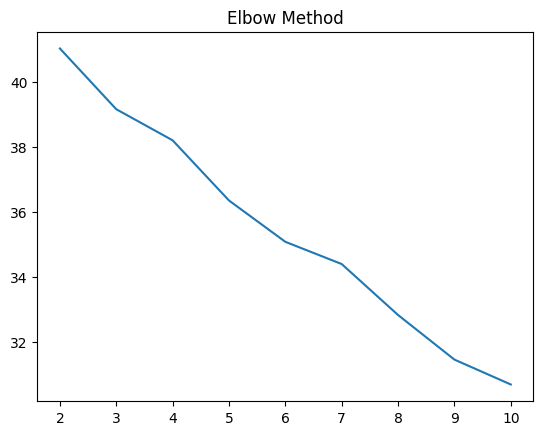

Graph Plotted. Please Analyze and Choose a cluster number based on graph.


Creating Model...


Extracted Topics: 

Topic 0
['legends', 'apex', 'fortnite', 'loba', 'gay', 'read', 'played', 'life', 'win', 'yesyesyesyesyes', 'step', 'friends', 'valkyrie', 'game', 'cute', 'wattson', 'hard', 'fun', 'battle', 'absolutely', 'changed', 'girlfriend', 'pretty', 'weewee', 'deserve', 'ea', 'royale', 'sexually', 'pathfinder', 'attracted', 'raging', 'likes', '45', 'thumbs', 'yesyesyesyes', 'players', 'play', 'father', 'games', 'feel', 'ut', 'playing', 'depressionand', 'depression', 'abilities', 'movement', 'matchmaking', 'gunplay', 'sleep', 'asap', 'healthy', '000', 'price', 'relationship', 'decent', 'schedule', 'breakdown', 'disorder', 'anxiety', 'erections', 'swings', 'racism', 'mood', 'bipolar', 'relationships', 'character', 'day', 'fastpaced', 'restart', 'recommend', 'origins', 'data', 'change', 'gamertag', 'yesyesyeyesyes', 'team', 'skill', 'playstyle', 'unique', 'mechanics', 'lot', 'time', 's

(KMeans(n_clusters=3, n_init=10, random_state=0),
 <Compressed Sparse Row sparse matrix of dtype 'float64'
 	with 897 stored elements and shape (46, 665)>,
 None)

In [35]:
extract_topics(positive_highs['Review']) # Optimal Input 3


Initializing Model...


Inertia Graph for Optimal Cluster Selection



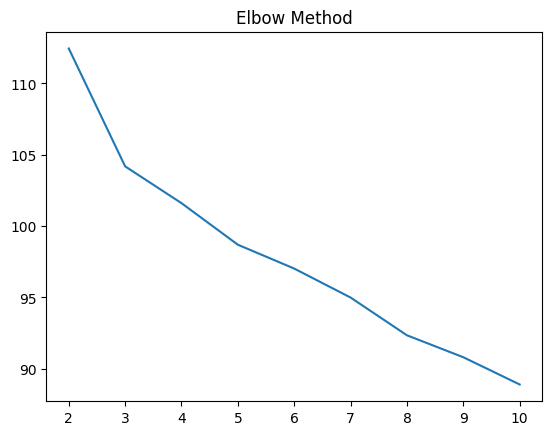

Graph Plotted. Please Analyze and Choose a cluster number based on graph.


Creating Model...


Extracted Topics: 

Topic 0
['pet', 'thumbs', 'cat', 'leave', 'passes', 'awards', 'friends', 'pass', 'rampart', 'passing', 'capybara', 'beautiful', 'steam', '1999', 'zip', '175', '15ounce', '15', '1440p', '14', '13', '12ounce', '121', '12', '11easy', '11', '10inch', '1010', '1000', '02s', 'womans', 'wolfhirschhorn', 'wolffparkinsonwhite', 'wisses', 'wise', 'wisdom', 'wire', 'wipes', 'wiped', 'wine', 'win', 'wilson', 'williams', 'willebrand', 'wife', 'wielded', 'wide', 'white', 'whiskey', 'whipped', 'wheel', 'wet', 'wellsmart', 'wegeners', 'week', 'wedges', 'weave', 'weapons', 'weapon', 'wattsons', 'wattson', 'watson', 'watermelon', 'water', 'watching', 'watch', 'warzone', 'warranted', 'wanna', 'walls', 'waiting', 'wait', 'vortex', 'von', 'voice', 'vodka', 'vocal', 'visuals', 'visual', 'virus', 'virgins', 'videos', 'vices', 'vestibular', 'vertigo', 'veins', 'vein', 'vegetable', 'vast', 'varie

(KMeans(n_clusters=3, n_init=10, random_state=0),
 <Compressed Sparse Row sparse matrix of dtype 'float64'
 	with 2737 stored elements and shape (133, 1702)>,
 None)

In [36]:
extract_topics(positive_lows['Review']) # Optimal Input 3


Initializing Model...




Inertia Graph for Optimal Cluster Selection



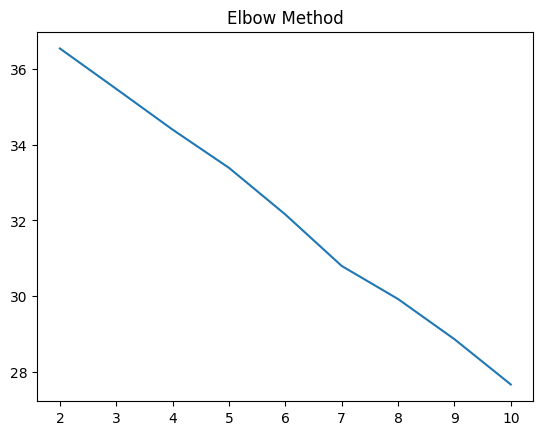

Graph Plotted. Please Analyze and Choose a cluster number based on graph.


Creating Model...


Extracted Topics: 

Topic 0
['trash', 'leaving', 'bad', 'review', 'server', 'servers', 'bruda', 'gender', 'gibbys', 'neutral', 'white', 'methbender', 'walter', 'gunplay', 'recommend', 'legends', 'game', 'banned', 'balancing', 'monetization', 'movement', 'hard', 'stuff', 'terrible', 'abilities', 'hours', 'fun', 'players', 'ea', 'games', 'fake', 'suicidal', '1k', 'lazy', '15', 'flaming', 'inconsistent', 'unbalanced', 'asf', 'znce', 'mess', 'product', 'promises', 'deserves', 'expensive', 'mechanics', '2500', 'cronus', 'god', 'solved', 'respawns', 'xbox', 'versions', 'stick', 'galore', 'stacks', 'regs', 'ttk', 'poverty', 'teamates', 'p2020s', 'cons', 'developers', 'maps', 'overpowered', '1600', 'useless', 'alot', 'grab', 'latency', 'moves', 'cosmetics', 'played', 'pros', 'guns', 'tick', 'basically', 'friends', 'start', 'horrible', 'leave', 'main', 'match', 'bugs', 'assist', 'pass', 'respawn', 'd

(KMeans(n_clusters=7, n_init=10, random_state=0),
 <Compressed Sparse Row sparse matrix of dtype 'float64'
 	with 2467 stored elements and shape (41, 1527)>,
 None)

In [37]:
extract_topics(negative_highs['Review']) # Optimal Input 7


Initializing Model...


Inertia Graph for Optimal Cluster Selection



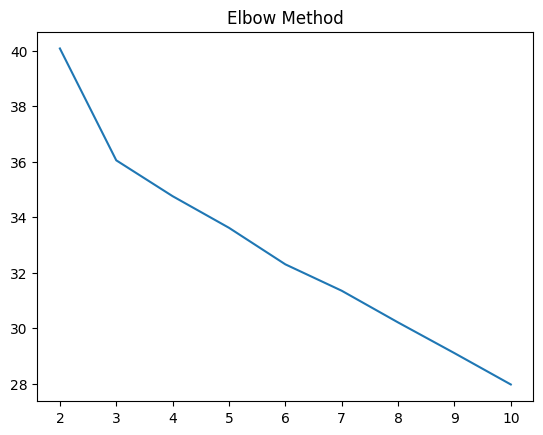

Graph Plotted. Please Analyze and Choose a cluster number based on graph.


Creating Model...


Extracted Topics: 

Topic 0
['game', 'apex', 'play', 'ea', 'season', 'servers', 'playing', 'trash', 'skins', 'players', 'respawn', 'legends', 'issues', 'matchmaking', 'people', 'bikini', 'fun', 'unplayable', 'bad', 'hours', 'time', 'update', 'review', 'money', 'day', 'level', 'games', 'account', 'crashing', 'tournament', 'streamer', 'support', 'decided', 'steam', 'read', 'dementia', 'lobbies', 'spend', 'started', 'hit', 'literally', 'pls', 'china', 'lock', 'region', 'snort', 'cocaine', 'skill', 'love', 'session', 'diamond', 'cheaters', 'issue', 'match', 'gameplay', 'crashed', 'gaming', 'devs', 'player', 'freezes', 'removed', 'played', 'ranked', 'cancer', 'supposed', 'fine', 'addicting', 'unhealthiest', 'communities', 'involved', 'legend', 'pass', 'completely', 'pc', 'gain', 'sad', 'predators', 'friends', 'minute', 'petty', 'penalty', 'abandon', 'heirloom', 'based', '100x', 'weapon', 'solo', 

(KMeans(n_clusters=3, n_init=10, random_state=0),
 <Compressed Sparse Row sparse matrix of dtype 'float64'
 	with 2297 stored elements and shape (48, 1581)>,
 None)

In [38]:
extract_topics(negative_lows['Review']) # Optimal nput 3


Initializing Model...


Inertia Graph for Optimal Cluster Selection



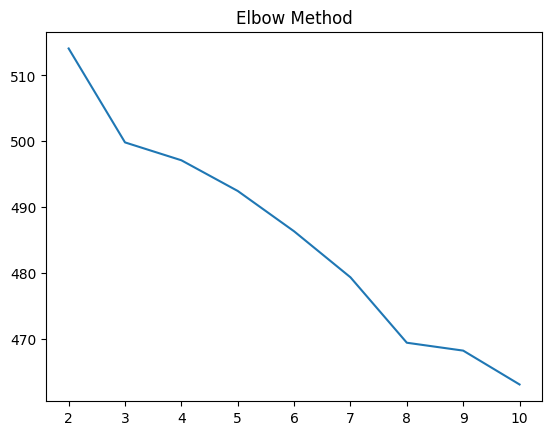

Graph Plotted. Please Analyze and Choose a cluster number based on graph.


Creating Model...


Extracted Topics: 

Topic 0
['win', 'apartment', 'complex', 'build', 'apex', 'architect', 'fun', 'octane', 'legend', 'zika', 'zest', 'zampella', 'zaidi', 'yucky', 'youtube', 'yonder', 'yolk', '11easy', '15ounce', '1510', '150', '15', '1440p', '14', '13inch', '1300', '13', '12ounce', '12k', '12673517612345', '1250', '121', 'yo', 'xbox', 'wrote', 'wrong', 'writing', 'wraiths', 'wraith', 'worthwhile', 'worth', 'worstrun', 'worst', 'worse', 'worry', 'worlds', 'worldbuilding', 'word', 'woowoo', 'wooooow', 'woohoo', 'wooden', 'wondering', 'wonderfully', 'wonderful', 'womans', 'wolfhirschhorn', 'wolffparkinsonwhite', 'wisses', 'wishing', 'wise', 'wisdom', 'wire', 'wiping', 'wipes', 'wiped', 'wipe', 'wins', 'winninggetting', 'winning', 'winner', 'wink', 'wingman', 'wine', 'window', 'wilson', 'williams', 'willebrand', 'wild', 'wife', 'wielded', 'widespread', 'wide', 'white', 'whiskey', 'whisked', 'wh

(KMeans(n_clusters=3, n_init=10, random_state=0),
 <Compressed Sparse Row sparse matrix of dtype 'float64'
 	with 10420 stored elements and shape (558, 4030)>,
 None)

In [39]:
extract_topics(all_positive['Review']) # Optimal Input 3


Initializing Model...


Inertia Graph for Optimal Cluster Selection



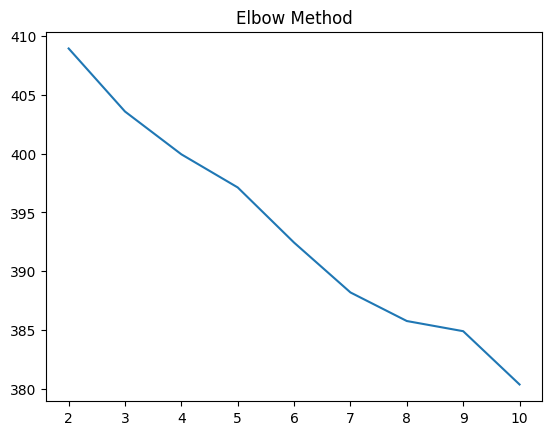

Graph Plotted. Please Analyze and Choose a cluster number based on graph.


Creating Model...


Extracted Topics: 

Topic 0
['gibbys', 'gender', 'bruda', 'neutral', 'christs', 'removed', '11', 'zens', 'yr', 'youwant', 'youtube', 'yoinked', 'yesterdays', 'yesterday', 'yellow', 'yeast', 'yearat', 'yeahthey', 'yeahh', 'yeah', 'yards', 'zombify', 'yall', 'ya', 'xd', 'xbox', 'wtf', 'wrote', 'wrong', 'written', 'writing', 'write', 'wretches', 'wraiths', 'wraithnaruto', 'wraith', 'wow', 'wound', 'wouldve', 'worthy', 'worthwhile', 'worth', 'worst', 'worshipers', 'worsereworked', 'worsend', 'worsen', 'worse', 'worry', 'worried', 'worlds', 'worldreal', 'word', 'wood', 'wonders', 'wonderland', 'wondering', 'wonderful', 'wondered', 'woman', 'wl', 'witness', 'withthats', 'witcher', 'wishes', 'wished', 'wise', 'wiping', 'wipe', 'wins', 'winrate', 'wingman', 'windows', 'win', 'willnotimplementsolos', 'wild', 'wifi', 'wife', 'wielding', 'widespread', 'wide', 'whopping', 'whooping', 'white', 'whisper',

(KMeans(n_clusters=7, n_init=10, random_state=0),
 <Compressed Sparse Row sparse matrix of dtype 'float64'
 	with 14141 stored elements and shape (442, 4772)>,
 None)

In [40]:
extract_topics(all_negative['Review']) # Optimal Input 7

# Visualization

In [41]:
box_df = df_new[['Hours on Account','isRecommended']].copy()
box_df['isRecommended'] = box_df['isRecommended'].map({0:'Not Recommended',1:'Recommended'})
box_df

,Hours on Account,isRecommended
0,41,Not Recommended
1,18656,Not Recommended
2,96,Recommended
3,11,Recommended
4,166,Recommended
...,...,...
995,8195,Not Recommended
996,1057,Not Recommended
997,18,Not Recommended
998,3316,Recommended


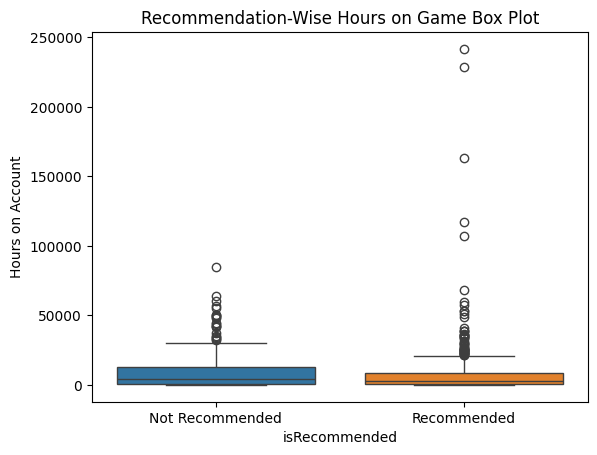

In [42]:
sns.boxplot(data = box_df, x = 'isRecommended', y = 'Hours on Account', hue = 'isRecommended')
plt.title('Recommendation-Wise Hours on Game Box Plot')
plt.show()

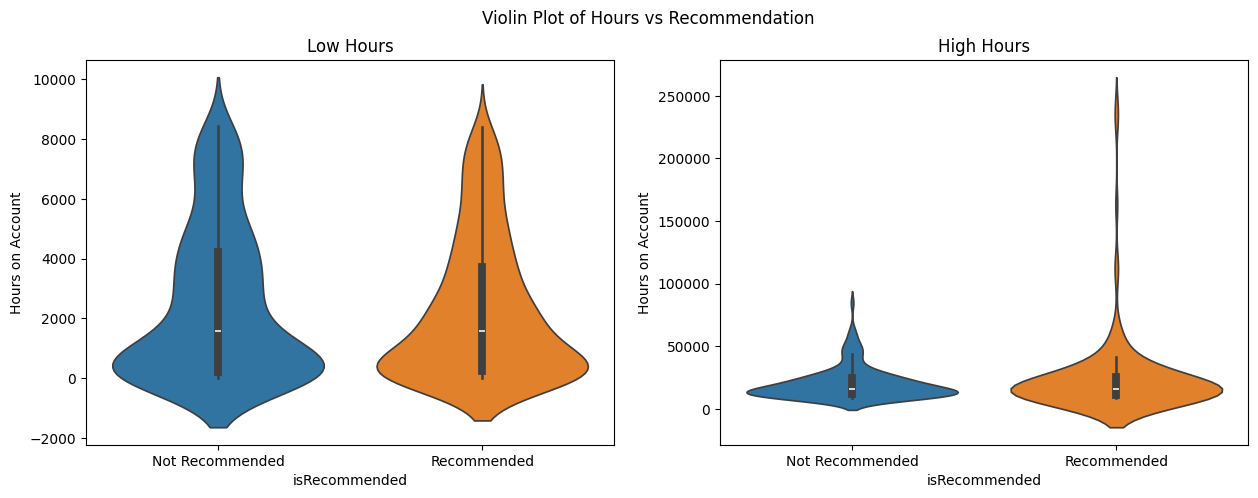

In [43]:
high_hours_df = box_df[box_df['Hours on Account'] > box_df['Hours on Account'].mean()].copy()
low_hours_df = box_df[box_df['Hours on Account'] <= box_df['Hours on Account'].mean()].copy()

fig, axs = plt.subplots(nrows = 1, ncols = 2, figsize = (15,5))

fig.suptitle('Violin Plot of Hours vs Recommendation')

sns.violinplot(low_hours_df[['Hours on Account','isRecommended']], x = 'isRecommended', y = 'Hours on Account', hue = 'isRecommended', ax = axs[0])
axs[0].set_title('Low Hours')

sns.violinplot(high_hours_df[['Hours on Account','isRecommended']], x = 'isRecommended', y = 'Hours on Account', hue = 'isRecommended', ax = axs[1])
axs[1].set_title('High Hours')

plt.show()

# I wanna see if the hours on the game affects whether the player would recommend it or not?

# Violin plot
# Left: Low Hours
# Right: High Hours

In [44]:
box_df

,Hours on Account,isRecommended
0,41,Not Recommended
1,18656,Not Recommended
2,96,Recommended
3,11,Recommended
4,166,Recommended
...,...,...
995,8195,Not Recommended
996,1057,Not Recommended
997,18,Not Recommended
998,3316,Recommended


In [45]:
box_df['Hours on Account'].describe()

count      1000.000000
mean       8478.611000
std       16197.627037
min           1.000000
25%         644.500000
50%        3609.500000
75%       10376.250000
max      241730.000000
Name: Hours on Account, dtype: float64

<Axes: >

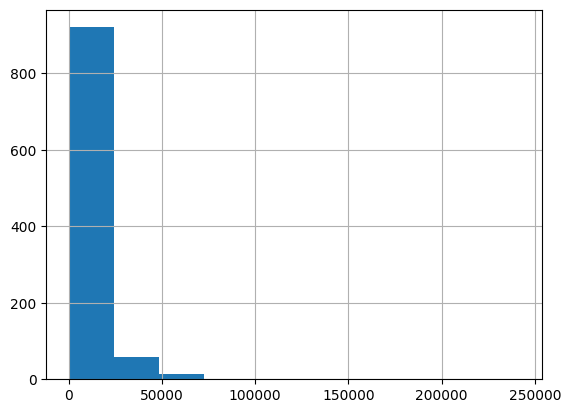

In [46]:
box_df['Hours on Account'].hist()

In [47]:
df_new.head()

,Author,Review,# of Comments,Products,Hours on Account,isRecommended,Users found review funny,Users found review helpful,Community Awards
0,Kaladin,2 10 dollar battle passes per season\n\nTitanf...,0,228,41,0,133,3796,178
1,KEVE,"Now with the new battle pass system, I'm delet...",78,42,18656,0,85,4370,186
2,⛧ M♱ropele ⛧,At least you don't have to build an apartment ...,54,655,96,1,2017,3089,500
3,to infinity and beyond,Finally I can remove Origin.,0,0,11,1,634,1770,103
4,chelovek bez vkusa,Finally here\n\nIt launches without Origin...\...,35,295,166,1,91,2109,49


In [48]:
numeric_df = df_new.select_dtypes(exclude = 'object')
column_order = [col for col in numeric_df.columns if col != 'isRecommended'] + ['isRecommended']
numeric_df = numeric_df[column_order]
numeric_df['isRecommended'] = numeric_df['isRecommended'].map({0:'Not Recommended',1:'Recommended'})
numeric_df

,# of Comments,Products,Hours on Account,Users found review funny,Users found review helpful,Community Awards,isRecommended
0,0,228,41,133,3796,178,Not Recommended
1,78,42,18656,85,4370,186,Not Recommended
2,54,655,96,2017,3089,500,Recommended
3,0,0,11,634,1770,103,Recommended
4,35,295,166,91,2109,49,Recommended
...,...,...,...,...,...,...,...
995,0,74,8195,1,14,0,Not Recommended
996,0,347,1057,0,11,0,Not Recommended
997,0,0,18,0,24,0,Not Recommended
998,0,162,3316,0,7,1,Recommended


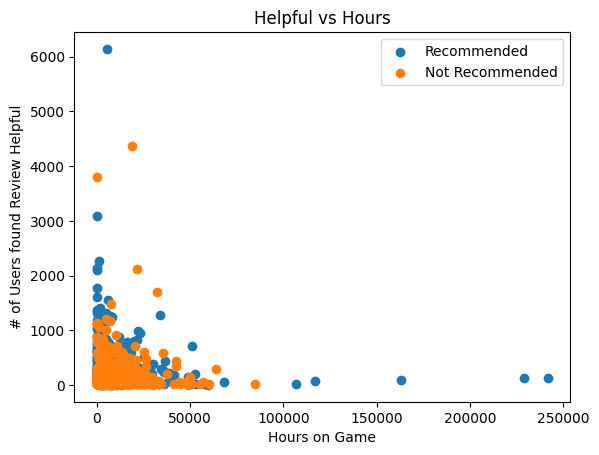

In [49]:
fig, ax = plt.subplots()

ax.scatter(
    data = numeric_df[numeric_df['isRecommended'] == 'Recommended'],
    y = 'Users found review helpful', 
    x = 'Hours on Account',
    label = 'Recommended'
)

ax.scatter(
    data = numeric_df[numeric_df['isRecommended'] == 'Not Recommended'],
    y = 'Users found review helpful', 
    x = 'Hours on Account',
    label = 'Not Recommended'
)

ax.set_title('Helpful vs Hours')
ax.set_ylabel('# of Users found Review Helpful')
ax.set_xlabel('Hours on Game')

plt.legend()
plt.show()

In [50]:
numeric_df[numeric_df['isRecommended'] == 'Not Recommended']['Hours on Account'].apply(np.log)

0      3.713572
1      9.833923
7      9.966368
8      8.961751
9      9.773550
         ...   
994    7.966933
995    9.011279
996    6.963190
997    2.890372
999    3.135494
Name: Hours on Account, Length: 442, dtype: float64

In [51]:
numeric_df[numeric_df['isRecommended'] == 'Not Recommended'][['Users found review helpful','Hours on Account']].apply(np.log)

,Users found review helpful,Hours on Account
0,8.241703,3.713572
1,8.382518,9.833923
7,7.659171,9.966368
8,7.304516,8.961751
9,6.184149,9.773550
...,...,...
994,1.945910,7.966933
995,2.639057,9.011279
996,2.397895,6.963190
997,3.178054,2.890372


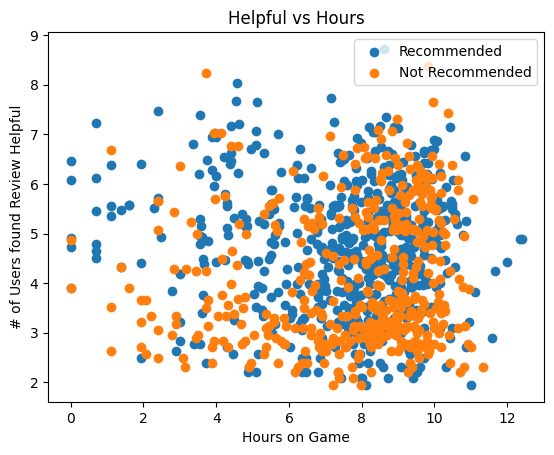

In [52]:
fig, ax = plt.subplots()

ax.scatter(
    data = numeric_df[numeric_df['isRecommended'] == 'Recommended'][['Users found review helpful','Hours on Account']].apply(np.log),
    y = 'Users found review helpful',
    x = 'Hours on Account',
    label = 'Recommended'
)

ax.scatter(
    data = numeric_df[numeric_df['isRecommended'] == 'Not Recommended'][['Users found review helpful','Hours on Account']].apply(np.log),
    y = 'Users found review helpful',
    x = 'Hours on Account',
    label = 'Not Recommended'
)

ax.set_title('Helpful vs Hours')
ax.set_ylabel('# of Users found Review Helpful')
ax.set_xlabel('Hours on Game')

plt.legend()
plt.show()

In [53]:
numeric_df[['Products', 'Hours on Account']].apply(np.log1p)

,Products,Hours on Account
0,5.433722,3.737670
1,3.761200,9.833977
2,6.486161,4.574711
3,0.000000,2.484907
4,5.690359,5.117994
...,...,...
995,4.317488,9.011402
996,5.852202,6.964136
997,0.000000,2.944439
998,5.093750,8.106816


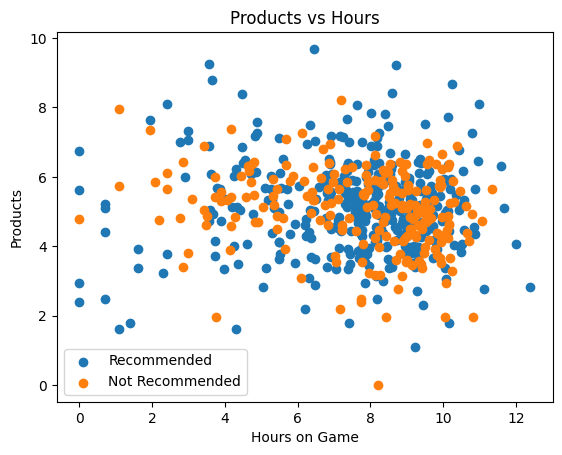

In [54]:
fig, ax = plt.subplots()

ax.scatter(
    data = numeric_df[numeric_df['isRecommended'] == 'Recommended'][['Products', 'Hours on Account']].apply(np.log),
    y = 'Products', 
    x = 'Hours on Account',
    label = 'Recommended'
)

ax.scatter(
    data = numeric_df[numeric_df['isRecommended'] == 'Not Recommended'][['Products', 'Hours on Account']].apply(np.log),
    y = 'Products', 
    x = 'Hours on Account',
    label = 'Not Recommended'
)

ax.set_title('Products vs Hours')
ax.set_ylabel('Products')
ax.set_xlabel('Hours on Game')

plt.legend()
plt.show()

### Categorizing Reviews

In [55]:
df_new.head()

,Author,Review,# of Comments,Products,Hours on Account,isRecommended,Users found review funny,Users found review helpful,Community Awards
0,Kaladin,2 10 dollar battle passes per season\n\nTitanf...,0,228,41,0,133,3796,178
1,KEVE,"Now with the new battle pass system, I'm delet...",78,42,18656,0,85,4370,186
2,⛧ M♱ropele ⛧,At least you don't have to build an apartment ...,54,655,96,1,2017,3089,500
3,to infinity and beyond,Finally I can remove Origin.,0,0,11,1,634,1770,103
4,chelovek bez vkusa,Finally here\n\nIt launches without Origin...\...,35,295,166,1,91,2109,49


# KMeans


Initializing Model...


Inertia Graph for Optimal Cluster Selection



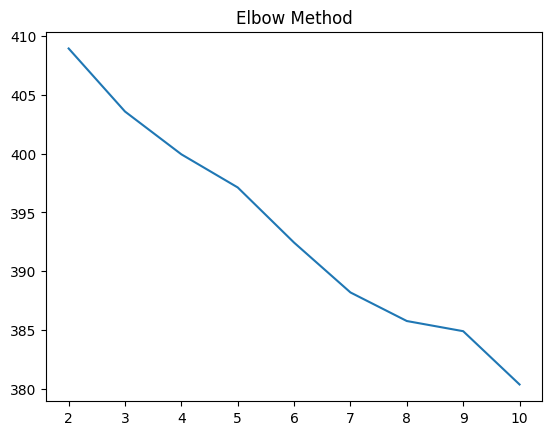

Graph Plotted. Please Analyze and Choose a cluster number based on graph.


Creating Model...


Extracted Topics: 

Topic 0
['gibbys', 'gender', 'bruda', 'neutral', 'christs', 'removed', '11', 'zens', 'yr', 'youwant', 'youtube', 'yoinked', 'yesterdays', 'yesterday', 'yellow', 'yeast', 'yearat', 'yeahthey', 'yeahh', 'yeah', 'yards', 'zombify', 'yall', 'ya', 'xd', 'xbox', 'wtf', 'wrote', 'wrong', 'written', 'writing', 'write', 'wretches', 'wraiths', 'wraithnaruto', 'wraith', 'wow', 'wound', 'wouldve', 'worthy', 'worthwhile', 'worth', 'worst', 'worshipers', 'worsereworked', 'worsend', 'worsen', 'worse', 'worry', 'worried', 'worlds', 'worldreal', 'word', 'wood', 'wonders', 'wonderland', 'wondering', 'wonderful', 'wondered', 'woman', 'wl', 'witness', 'withthats', 'witcher', 'wishes', 'wished', 'wise', 'wiping', 'wipe', 'wins', 'winrate', 'wingman', 'windows', 'win', 'willnotimplementsolos', 'wild', 'wifi', 'wife', 'wielding', 'widespread', 'wide', 'whopping', 'whooping', 'white', 'whisper',

In [56]:
negative_model, negative_document_X, negative_vocab = extract_topics(all_negative['Review'], getModel = True)

In [57]:
negative_topics = {
    0: "Streaming from Social Platforms",
    1: "Removed Gamemodes",
    2: "Titanfall is better",
    3: "OS support",
    4: "Microtransactions and Payment",
    5: "Server Issues",
    6: "Bad Matchmaking"
}

In [58]:
all_negative['Category'] = negative_model.predict(negative_document_X)
all_negative['Category'] = all_negative['Category'].map(negative_topics)
all_negative

,Author,Review,# of Comments,Products,Hours on Account,isRecommended,Users found review funny,Users found review helpful,Community Awards,Category
0,Kaladin,2 10 dollar battle passes per season\n\nTitanf...,0,228,41,0,133,3796,178,Titanfall is better
1,KEVE,"Now with the new battle pass system, I'm delet...",78,42,18656,0,85,4370,186,Server Issues
7,🐾Gizmo🐾,We don't have a cheater problem.\nOk we do hav...,48,508,21298,0,85,2120,211,OS support
8,Blödhgarm,"I've got nearly 3k hours in this game, most of...",0,0,7799,0,28,1487,247,Server Issues
9,DeeDee MegaDooDoo,"I've been playing this game since release, and...",16,0,17563,0,21,485,59,Server Issues
...,...,...,...,...,...,...,...,...,...,...
994,TTV Tarquar_,♥♥♥♥ GAME NEEDS A SOLO MODE. ALL MY TEAMATES A...,3,25,2884,0,1,7,0,Server Issues
995,Mayano Top Gun,GAME NGENTOD,0,74,8195,0,1,14,0,Server Issues
996,Dubinn,"Used to love it, now look at what they did to ...",0,347,1057,0,0,11,0,Bad Matchmaking
997,Fiery,You removed linux support? AI cheats basically...,0,0,18,0,0,24,0,OS support


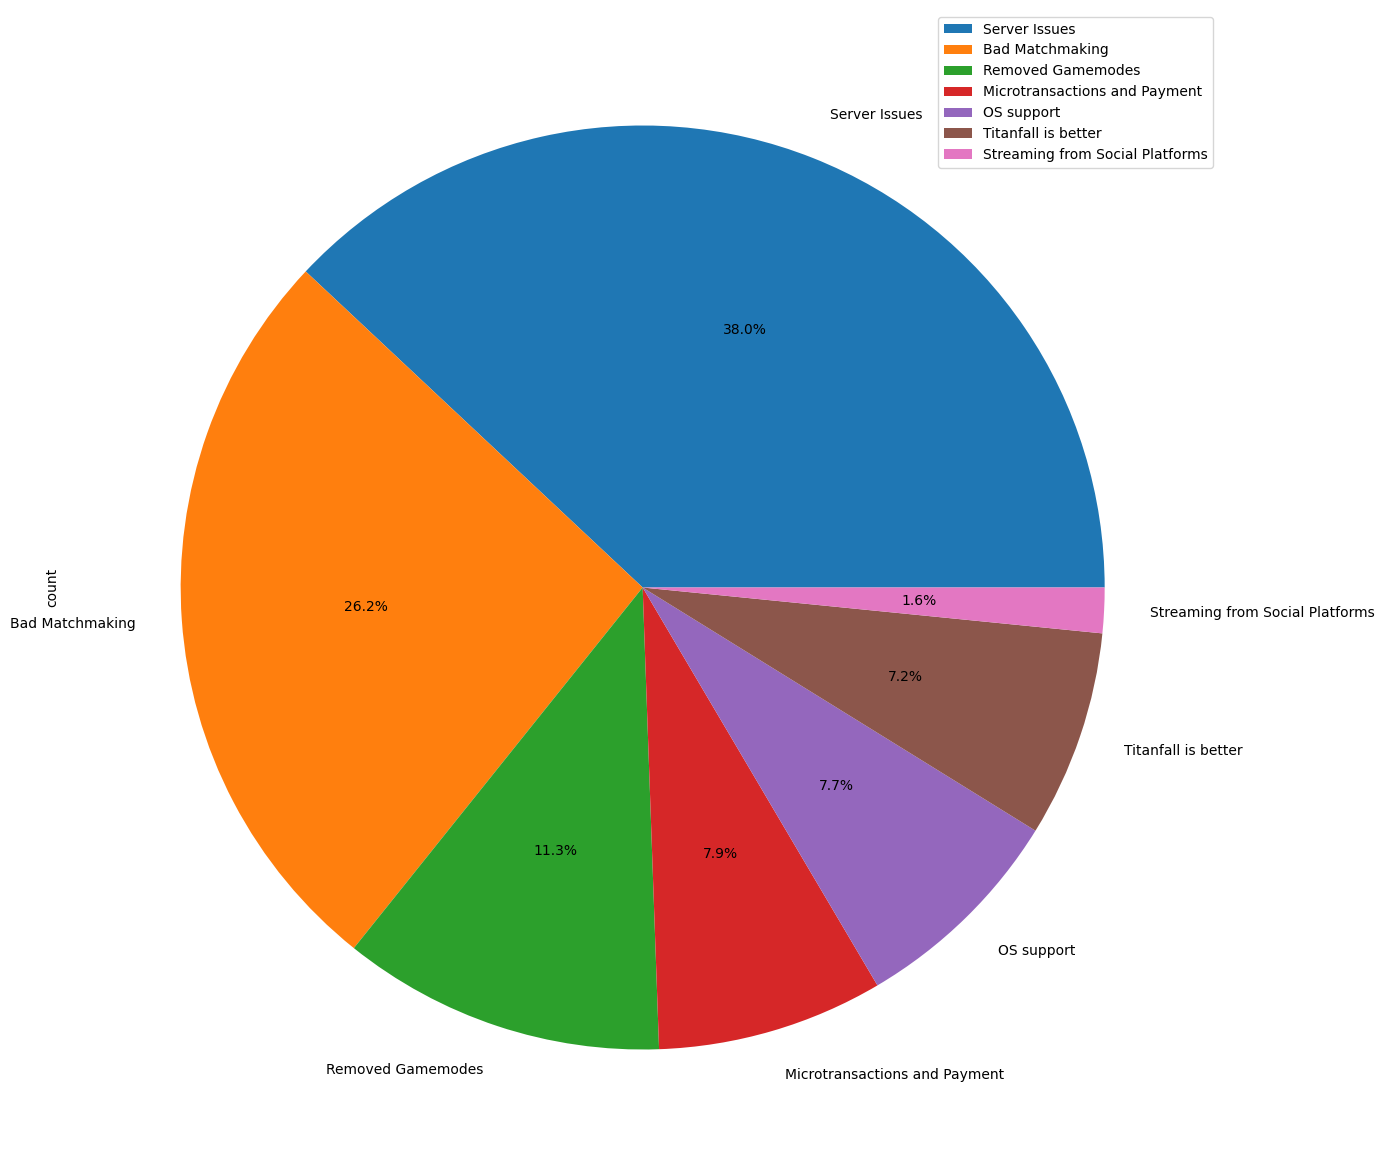

In [59]:
(
    all_negative['Category']
    .value_counts()
    .reset_index()
    .set_index('Category')
    .plot(
            kind = 'pie',
            y = 'count',
            figsize = (15, 15),
            autopct = '%.1f%%'
        )
)
plt.legend(loc = 'upper right')
plt.show()


Initializing Model...


Inertia Graph for Optimal Cluster Selection



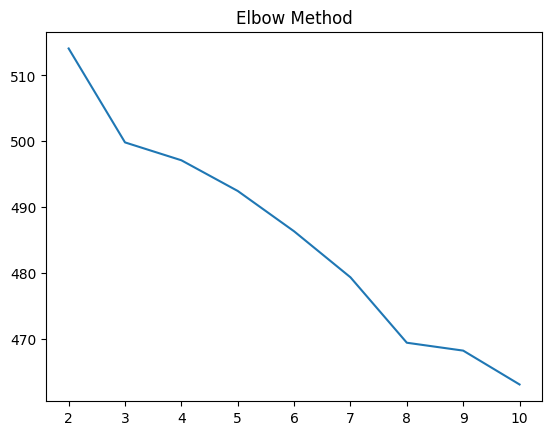

Graph Plotted. Please Analyze and Choose a cluster number based on graph.


Creating Model...


Extracted Topics: 

Topic 0
['win', 'apartment', 'complex', 'build', 'apex', 'architect', 'fun', 'octane', 'legend', 'zika', 'zest', 'zampella', 'zaidi', 'yucky', 'youtube', 'yonder', 'yolk', '11easy', '15ounce', '1510', '150', '15', '1440p', '14', '13inch', '1300', '13', '12ounce', '12k', '12673517612345', '1250', '121', 'yo', 'xbox', 'wrote', 'wrong', 'writing', 'wraiths', 'wraith', 'worthwhile', 'worth', 'worstrun', 'worst', 'worse', 'worry', 'worlds', 'worldbuilding', 'word', 'woowoo', 'wooooow', 'woohoo', 'wooden', 'wondering', 'wonderfully', 'wonderful', 'womans', 'wolfhirschhorn', 'wolffparkinsonwhite', 'wisses', 'wishing', 'wise', 'wisdom', 'wire', 'wiping', 'wipes', 'wiped', 'wipe', 'wins', 'winninggetting', 'winning', 'winner', 'wink', 'wingman', 'wine', 'window', 'wilson', 'williams', 'willebrand', 'wild', 'wife', 'wielded', 'widespread', 'wide', 'white', 'whiskey', 'whisked', 'wh

In [60]:
positive_model, positive_document_X, positive_vocab = extract_topics(all_positive['Review'], getModel = True) # Optimal Input 3

In [61]:
positive_topics = {
    0: 'Unlike Fortnite',
    1: 'Emotes and Friends',
    2: 'Removal of Origin Launcher'
}

In [62]:
all_positive['Category'] = positive_model.predict(positive_document_X)
all_positive['Category'] = all_positive['Category'].map(positive_topics)
all_positive

,Author,Review,# of Comments,Products,Hours on Account,isRecommended,Users found review funny,Users found review helpful,Community Awards,Category
2,⛧ M♱ropele ⛧,At least you don't have to build an apartment ...,54,655,96,1,2017,3089,500,Unlike Fortnite
3,to infinity and beyond,Finally I can remove Origin.,0,0,11,1,634,1770,103,Removal of Origin Launcher
4,chelovek bez vkusa,Finally here\n\nIt launches without Origin...\...,35,295,166,1,91,2109,49,Removal of Origin Launcher
5,Shanks,uninstall origin,0,0,161,1,281,1180,64,Removal of Origin Launcher
6,azure,doesnt launch with origin\n\nedit: easy anti-c...,117,195,5460,1,915,6142,355,Removal of Origin Launcher
...,...,...,...,...,...,...,...,...,...,...
978,L a s w i n k a,"I will leave the cat here, so that everybody w...",0,81,4183,1,4,71,11,Emotes and Friends
979,Rest.N.Pieces,Product received for free\n\nits super duper f...,0,0,8417,1,4,29,3,Removal of Origin Launcher
985,Dayonica,"Buff Loba pls))0 (Posted 20 July, 2021.)\n\nIT...",0,85,25933,1,5,22,1,Removal of Origin Launcher
990,Sonder,"I had an entire family, went through a divorce...",1,562,5345,1,10,10,3,Removal of Origin Launcher


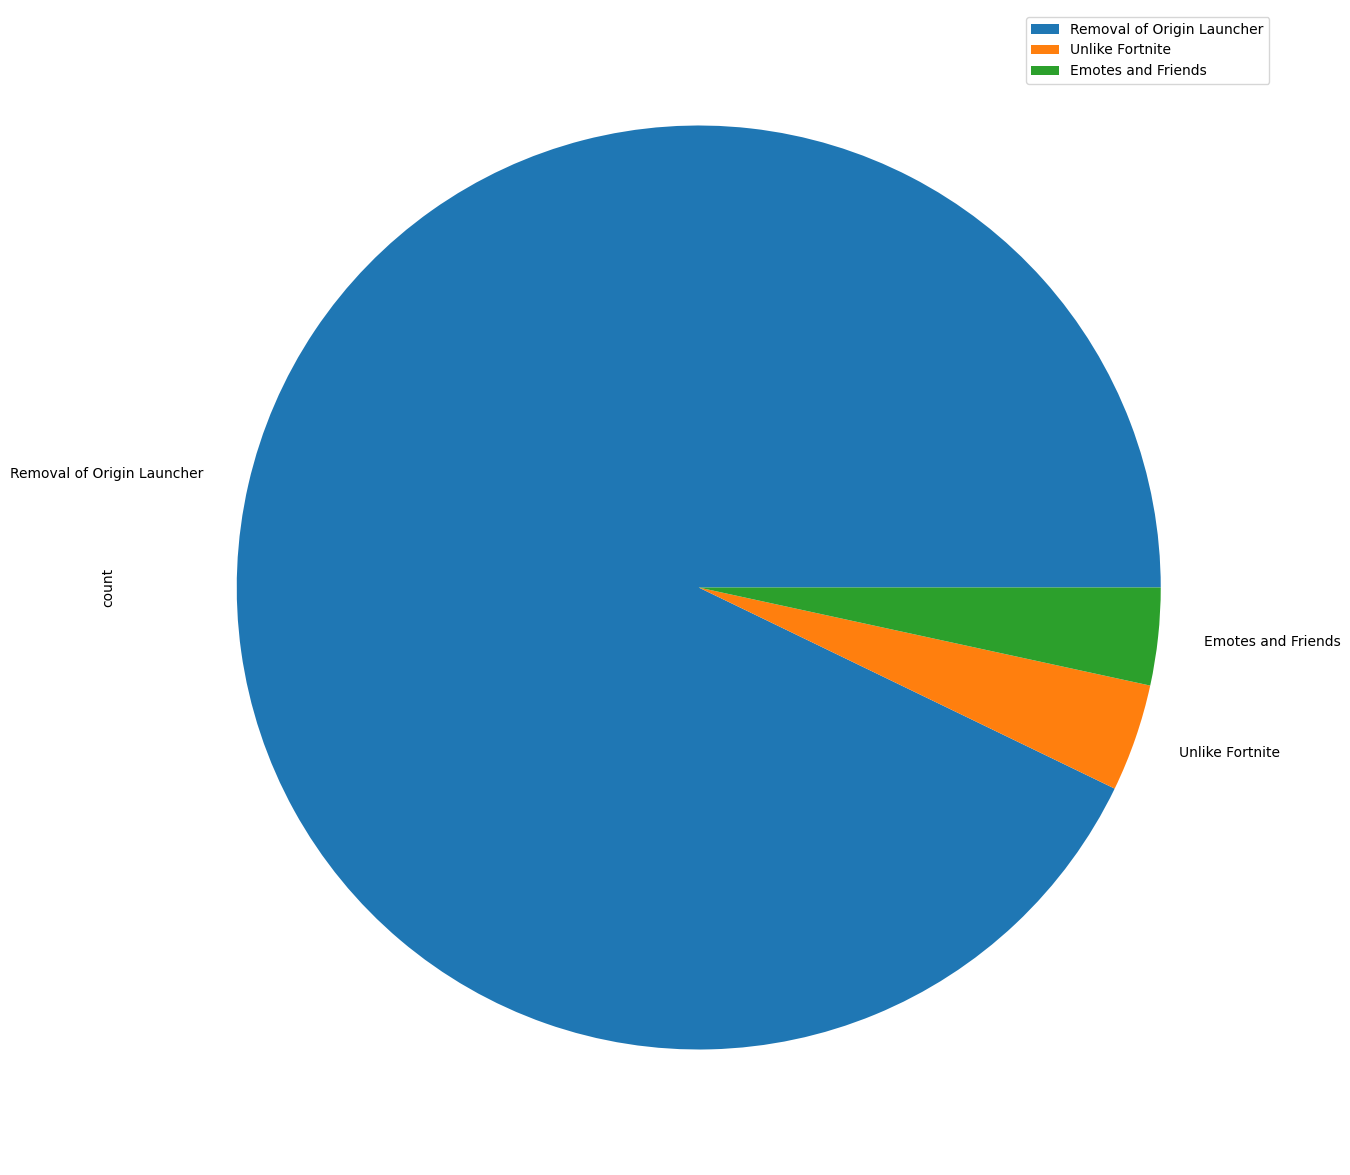

In [63]:
(
    all_positive['Category']
    .value_counts()
    .reset_index()
    .set_index('Category')
    .plot(
            kind = 'pie',
            y = 'count',
            figsize = (15, 15)
        )
)
plt.legend(loc = 'upper right')
plt.show()

In [108]:
silhouette_negative = silhouette_score(negative_document_X, negative_model.predict(negative_document_X))

silhouette_positive = silhouette_score(positive_document_X, positive_model.predict(positive_document_X))

print('Silhouette Score for Negative Review Topics: {}'.format(silhouette_negative))
print('Silhouette Score for Positive Review Topics: {}'.format(silhouette_positive))

Silhouette Score for Negative Review Topics: 0.04568509111139485
Silhouette Score for Positive Review Topics: 0.05350337684485115


# LDA

In [64]:
# Download stopwords from nltk only once
# import nltk

# nltk.download('stopwords')

In [65]:
def tokenize(text: str) -> list[str]:
    # Clean text by removing non-alphanumeric characters
    text = re.sub('[^a-zA-Z0-9 ]', '', text)
    
    # Split words into non-stopword lowercase words
    texts = [word for word in text.lower().split() if word not in stopwords.words('english')]

    return texts
    

In [66]:
negative_gensim_docs = [tokenize(doc) for doc in all_negative['Review'].tolist()]

In [67]:
negative_dictionary = Dictionary(negative_gensim_docs)

In [68]:
if len(negative_dictionary.id2token) == 0:
    _ = negative_dictionary[0]

negative_gensim_corpus = [negative_dictionary.doc2bow(texts) for texts in negative_gensim_docs]
negative_lda = LdaModel(negative_gensim_corpus, num_topics = 5, id2word = negative_dictionary.id2token)

In [69]:
negative_gensim_corpus[0]

[(0, 1), (1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (6, 1), (7, 1), (8, 1)]

In [70]:
negative_lda.print_topics()

[(0,
  '0.021*"game" + 0.007*"play" + 0.006*"players" + 0.006*"apex" + 0.006*"dont" + 0.005*"time" + 0.005*"like" + 0.005*"ea" + 0.004*"games" + 0.004*"even"'),
 (1,
  '0.025*"game" + 0.007*"get" + 0.006*"players" + 0.005*"play" + 0.005*"dont" + 0.005*"even" + 0.005*"time" + 0.005*"apex" + 0.004*"hours" + 0.004*"season"'),
 (2,
  '0.028*"game" + 0.008*"get" + 0.007*"apex" + 0.006*"even" + 0.006*"time" + 0.006*"like" + 0.005*"players" + 0.005*"every" + 0.005*"season" + 0.005*"new"'),
 (3,
  '0.036*"game" + 0.007*"play" + 0.007*"apex" + 0.006*"like" + 0.005*"time" + 0.005*"even" + 0.005*"players" + 0.005*"get" + 0.005*"good" + 0.005*"servers"'),
 (4,
  '0.021*"game" + 0.008*"play" + 0.006*"dont" + 0.005*"ea" + 0.005*"want" + 0.004*"matchmaking" + 0.004*"apex" + 0.004*"people" + 0.004*"players" + 0.004*"games"')]

In [71]:
negative_coherence = CoherenceModel(
    model = negative_lda,
    texts = negative_gensim_docs,
    corpus = negative_gensim_corpus,
    dictionary = negative_dictionary
)

In [72]:
negative_coherence.get_coherence()

np.float64(0.4749005543949649)

In [73]:
def get_optimal_lda(corpus: list[tuple[int,int]], dictionary: Dictionary, texts: list[list[str]], coherence_method: str = 'c_v', start: int = 1, end: int = 10) -> tuple[int,float]:
    # Variables to store coherence for plot
    coherences = []
    optimal_topics = (-1, -1)
    optimal_model = None
    
    # Find optimal Lda
    for i in range(start, end + 1):
        # Call dictionary to trigger lazy loading for id2token attribute
        _ = dictionary[0]
        
        lda = LdaModel(corpus = corpus, num_topics = i, id2word = dictionary.id2token, random_state = 42)
        
        coherence = CoherenceModel(model = lda, texts = texts, corpus = corpus, dictionary = dictionary, coherence = coherence_method).get_coherence()
        
        coherences.append(coherence)
        
        # Get Best Model
        if coherence > optimal_topics[1]:
            optimal_topics = (i, coherence)
            optimal_model = lda
        
        # Print Progress
        print(f'{i}/{end} Done')
    
    # Plot coherence
    fig, ax = plt.subplots(figsize = (15,12))
    
    ax.plot(range(start, end + 1), coherences)
    ax.set_ylabel('Coherence')
    ax.set_xlabel('Number of Topics')
    ax.set_title('Coherence vs Num Topics Plot')
    plt.show()
    
    return optimal_model, optimal_topics


1/10 Done
2/10 Done
3/10 Done
4/10 Done
5/10 Done
6/10 Done
7/10 Done
8/10 Done
9/10 Done
10/10 Done


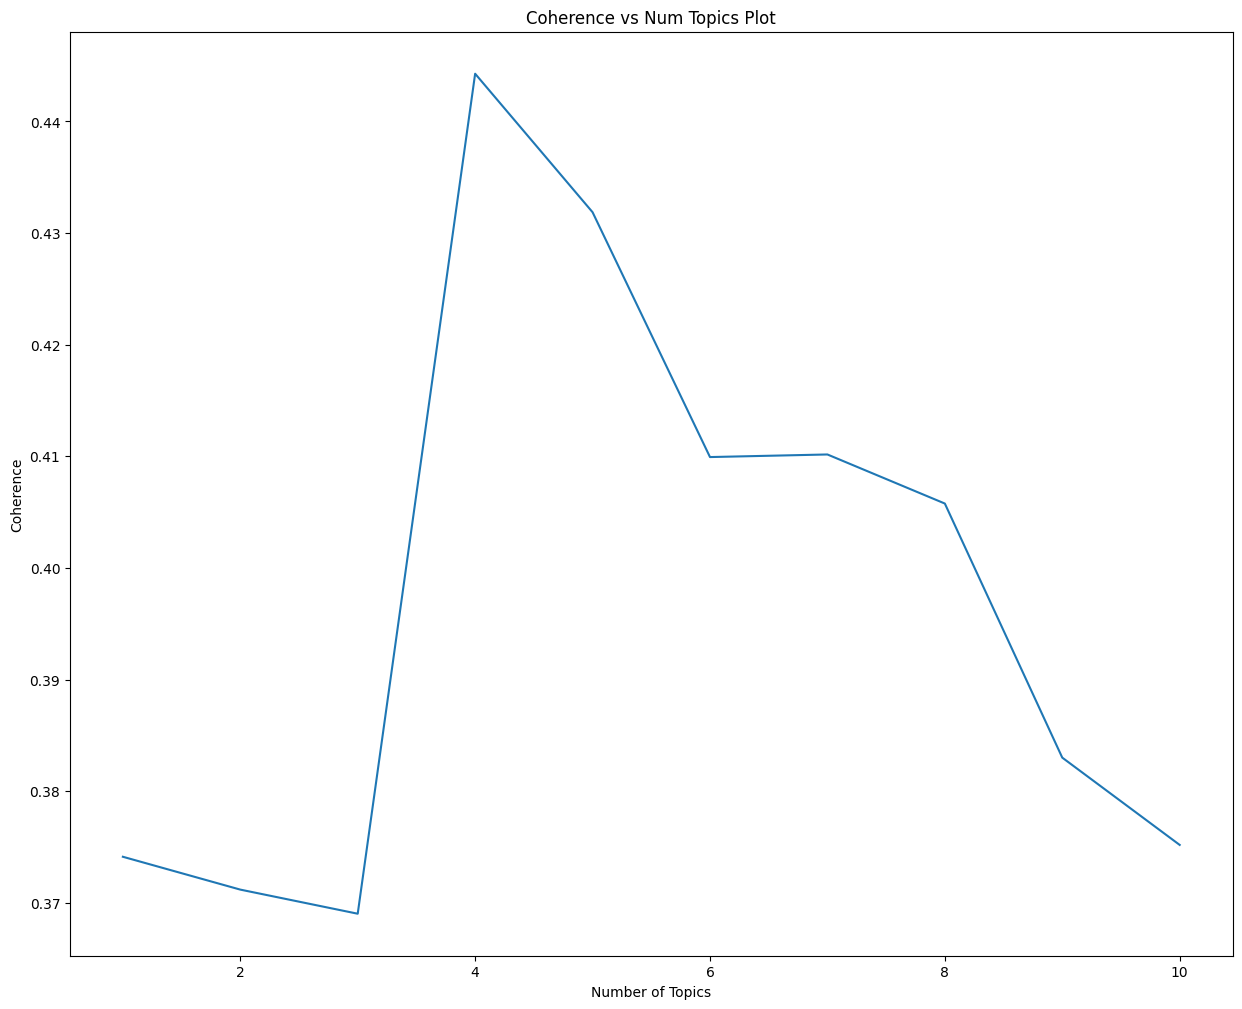

In [74]:
lda_model, optimal_topics = get_optimal_lda(negative_gensim_corpus, negative_dictionary, negative_gensim_docs)

In [75]:
print(optimal_topics)

(4, np.float64(0.44427022567816854))


In [77]:
vocab = [negative_dictionary.id2token[word] for word in negative_dictionary.cfs.keys()]
freq = [freq for freq in negative_dictionary.cfs.values()]

In [ ]:
# silence deprecation warnings from gensimvis
import warnings
warnings.filterwarnings(action = 'ignore', category = DeprecationWarning)

In [107]:
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

vis_data = gensimvis.prepare(lda_model, negative_gensim_corpus, negative_dictionary)
pyLDAvis.display(vis_data)